# XGBoost — Prédiction de la Gravité des Accidents Routiers (2024)

**Objectif :** Prédire la gravité d'un accident routier parmi trois classes :
- `0` — Blessé léger
- `1` — Blessé hospitalisé
- `2` — Tué

à partir de 12 variables contextuelles (luminosité, météo, type de route, vitesse, région, etc.)
en utilisant un modèle **XGBoost (Extreme Gradient Boosting)**.

**Données utilisées :** `X_lab_encoded.csv` (encodage ordinal, 12 colonnes)  
**Auteur :** Enzo

## Démarche

1. Chargement et split stratifié 80/20 (`train_test_split`, `random_state=42`), identique aux trois modèles pour une comparaison équitable
2. Baseline de référence (`DummyClassifier`) pour quantifier la valeur ajoutée du modèle
3. XGBoost avec `class_weight` pour gérer le déséquilibre 11×
4. Tuning par `RandomizedSearchCV` (50 itérations, 5-Fold CV)
5. Affinement final avec **early stopping** pour trouver le `n_estimators` optimal
6. **Calibration des probabilités** (correction du biais induit par `class_weight`)
7. **Optimisation du seuil de décision** sur la classe `Tué`
8. Évaluation finale et interprétation (SHAP, feature importance)

---

## 1. Imports & Configuration

In [31]:
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBClassifier

from sklearn.dummy import DummyClassifier
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.model_selection import (
    RandomizedSearchCV, train_test_split, learning_curve
)
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, precision_recall_curve, average_precision_score
)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings('ignore')
RANDOM_STATE = 42

## 2. Chargement des données

In [32]:
path = "donnees/clean/"
X = pd.read_csv(path + "X_lab_encoded.csv")
y = pd.read_csv(path + "y_gravite.csv").squeeze()

with open(path + "label_encoding_mappings.json", "r", encoding="utf-8") as f:
    mappings = json.load(f)

print(f"Shape X : {X.shape}")
print(f"Shape y : {y.shape}")
print(f"\nDistribution de la cible :")
print(y.value_counts(normalize=True).round(3))

Shape X : (54401, 12)
Shape y : (54401,)

Distribution de la cible :
Gravité (label)
0    0.639
1    0.302
2    0.059
Name: proportion, dtype: float64


## 3. Split Train / Test — stratifié 80/20

On sépare les données en 80 % entraînement / 20 % test avec `train_test_split`,
stratifié sur la cible et `random_state=42`. Ce découpage est **identique à celui
de la Régression Logistique et du Random Forest**, ce qui garantit que les trois
modèles sont comparés sur exactement le même jeu de test.

Remarque : le nettoyage a conservé 13 221 doublons exacts (24 %), chaque ligne
correspondant à un usager distinct. Un split stratifié peut donc placer deux
usagers d'un même accident de part et d'autre du split (légère fuite de données).
Nous avons envisagé un split groupé par signature d'accident pour l'éviter, mais
avons retenu le split stratifié standard afin de préserver la comparabilité entre
modèles ; cette fuite résiduelle est assumée comme limite (cf. rapport §6.3).

In [33]:
# Split aligné sur les 3 modèles : stratifié 80/20, random_state=42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
X_train = X_train.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

print("Shapes :")
print(f"  X_train : {X_train.shape}")
print(f"  X_test  : {X_test.shape}")

print("\nDistribution y_train :")
print(y_train.value_counts(normalize=True).round(3))

print("\nDistribution y_test :")
print(y_test.value_counts(normalize=True).round(3))

Shapes :
  X_train : (43520, 12)
  X_test  : (10881, 12)

Distribution y_train :
Gravité (label)
0    0.639
1    0.302
2    0.059
Name: proportion, dtype: float64

Distribution y_test :
Gravité (label)
0    0.639
1    0.302
2    0.059
Name: proportion, dtype: float64


## 4. Vérification des valeurs manquantes

XGBoost gère nativement les NaN — il apprend à chaque nœud la direction optimale
pour les observations manquantes. Aucune imputation n'est donc nécessaire.

In [34]:
valeurs_manquantes = X_train.isna().sum()
print("Valeurs manquantes par colonne :")
print(valeurs_manquantes[valeurs_manquantes > 0])

Valeurs manquantes par colonne :
Météo (conditions atmos.)      10
Vitesse_num                   604
Voies_num                    1788
dtype: int64


## 5. Gestion du déséquilibre de classes

Avec un ratio 11× entre la classe majoritaire (63.9 %) et la classe minoritaire (5.9 %),
un modèle non corrigé apprendrait à prédire systématiquement `Blessé léger`.
On utilise `compute_class_weight` pour pondérer chaque observation selon sa classe,
passé ensuite à `.fit()` via `sample_weight`.

In [35]:
# 1. Calcul des poids par classe (plus la classe est rare, plus le poids est élevé)
poids = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1, 2]),
    y=y_train
)
poids_dict = {0: poids[0], 1: poids[1], 2: poids[2]}
print(f"Poids par classe : {poids_dict}")

# 2. Vecteur de poids par observation
sample_weights = y_train.map(poids_dict)

Poids par classe : {0: np.float64(0.5219351898491281), 1: np.float64(1.103588183086091), 2: np.float64(5.620560506263722)}


## 6. Baseline — `DummyClassifier`

Avant tout modèle sérieux, on établit un baseline aléatoire pour quantifier l'apport de XGBoost.
Le `DummyClassifier` en mode `stratified` prédit chaque classe avec la même probabilité que sa
fréquence d'apparition dans le train. Tout F1 macro nettement supérieur à 0.33 (= 1/3 classes)
indique que le modèle apprend réellement quelque chose.

In [36]:
dummy = DummyClassifier(strategy='stratified', random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

print("=== Baseline DummyClassifier (stratified) ===")
print(classification_report(y_test, y_pred_dummy,
                            target_names=['Blessé léger', 'Hospitalisé', 'Tué']))

=== Baseline DummyClassifier (stratified) ===
              precision    recall  f1-score   support

Blessé léger       0.64      0.65      0.65      6949
 Hospitalisé       0.31      0.31      0.31      3287
         Tué       0.05      0.05      0.05       645

    accuracy                           0.51     10881
   macro avg       0.33      0.33      0.33     10881
weighted avg       0.51      0.51      0.51     10881



## 7. Modèle XGBoost par défaut (avec `class_weight`)

Entraînement d'un XGBoost avec les paramètres par défaut **mais en utilisant les `sample_weight`**
pour gérer le déséquilibre. Ce sera notre référence avant tuning.

In [37]:
model_default = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    random_state=RANDOM_STATE,
    eval_metric='mlogloss'
)
model_default.fit(X_train, y_train, sample_weight=sample_weights)

y_pred_default = model_default.predict(X_test)
print("=== XGB par défaut + class_weight ===")
print(classification_report(y_test, y_pred_default,
                            target_names=['Blessé léger', 'Hospitalisé', 'Tué']))

=== XGB par défaut + class_weight ===
              precision    recall  f1-score   support

Blessé léger       0.82      0.70      0.76      6949
 Hospitalisé       0.45      0.40      0.42      3287
         Tué       0.16      0.51      0.24       645

    accuracy                           0.60     10881
   macro avg       0.48      0.54      0.47     10881
weighted avg       0.67      0.60      0.62     10881



## 8. Optimisation des hyperparamètres — `RandomizedSearchCV`

`RandomizedSearchCV` tire 30 combinaisons aléatoires dans la grille de paramètres,
chacune évaluée en validation croisée 5-Fold. Plus efficace que `GridSearchCV`
qui testerait l'ensemble des combinaisons (plusieurs milliers).

Le scoring `f1_macro` accorde un poids égal aux 3 classes — adapté à notre déséquilibre.

In [38]:
param_grid = {
    'n_estimators':     [100, 200, 300, 500],
    'max_depth':        [3, 4, 5, 6, 7, 8],
    'learning_rate':    [0.01, 0.05, 0.1, 0.2, 0.3],
    'subsample':        [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0]
}

xgb_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        objective='multi:softprob', num_class=3,
        random_state=RANDOM_STATE, eval_metric='mlogloss'
    ),
    param_distributions=param_grid,
    n_iter=30,
    cv=5,
    scoring='f1_macro',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

In [39]:
# /!\ Cette cellule prend environ 5 à 10 minutes selon la machine
xgb_search.fit(X_train, y_train, sample_weight=sample_weights)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier..._class=3, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.6, 0.7, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], 'n_estimators': [100, 200, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be u

In [40]:
print(f"Meilleurs paramètres : {xgb_search.best_params_}")
print(f"Meilleur F1 macro (CV) : {xgb_search.best_score_:.3f}")

Meilleurs paramètres : {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
Meilleur F1 macro (CV) : 0.536


In [41]:
y_pred_tuned = xgb_search.predict(X_test)
print("=== XGB tuné (sans early stopping) ===")
print(classification_report(y_test, y_pred_tuned,
                            target_names=['Blessé léger', 'Hospitalisé', 'Tué']))

=== XGB tuné (sans early stopping) ===
              precision    recall  f1-score   support

Blessé léger       0.82      0.70      0.76      6949
 Hospitalisé       0.44      0.34      0.39      3287
         Tué       0.16      0.60      0.25       645

    accuracy                           0.59     10881
   macro avg       0.48      0.55      0.47     10881
weighted avg       0.67      0.59      0.62     10881



## 9. Affinement final avec `early_stopping`

Le tuning ci-dessus fixe `n_estimators` à une valeur donnée pour chaque combinaison.
**L'early stopping** permet de trouver automatiquement le nombre optimal d'arbres :
on arrête d'ajouter des arbres dès que la `mlogloss` sur un set de validation cesse de progresser
pendant 20 itérations consécutives.

Avantages :
- Évite l'overfitting (on n'ajoute pas d'arbres inutiles)
- Trouve automatiquement le bon `n_estimators` (au lieu de le tester dans la grille)

On extrait 20 % du train pour servir de validation pendant l'early stopping.

In [42]:
# Hold-out validation pour l'early stopping
X_tr, X_val, y_tr, y_val, sw_tr, sw_val = train_test_split(
    X_train, y_train, sample_weights,
    test_size=0.2, random_state=RANDOM_STATE, stratify=y_train
)
print(f"X_tr : {X_tr.shape}, X_val : {X_val.shape}")

X_tr : (34816, 12), X_val : (8704, 12)


In [43]:
# On reprend les meilleurs paramètres, mais on monte n_estimators très haut
# pour laisser l'early stopping décider du nombre optimal
best_params = dict(xgb_search.best_params_)
best_params['n_estimators'] = 1000  # plafond haut

model_es = XGBClassifier(
    objective='multi:softprob', num_class=3,
    random_state=RANDOM_STATE, eval_metric='mlogloss',
    early_stopping_rounds=20,
    **best_params
)
model_es.fit(X_tr, y_tr, sample_weight=sw_tr,
             eval_set=[(X_val, y_val)], verbose=False)

n_estim_optimal = model_es.best_iteration + 1
print(f"n_estimators optimal trouvé par early stopping : {n_estim_optimal}")
print(f"(au lieu de {xgb_search.best_params_['n_estimators']} initialement)")

n_estimators optimal trouvé par early stopping : 688
(au lieu de 200 initialement)


In [44]:
y_pred_es = model_es.predict(X_test)
print("=== XGB tuné + early stopping ===")
print(classification_report(y_test, y_pred_es,
                            target_names=['Blessé léger', 'Hospitalisé', 'Tué']))

=== XGB tuné + early stopping ===
              precision    recall  f1-score   support

Blessé léger       0.82      0.70      0.76      6949
 Hospitalisé       0.44      0.39      0.41      3287
         Tué       0.16      0.53      0.25       645

    accuracy                           0.60     10881
   macro avg       0.48      0.54      0.47     10881
weighted avg       0.67      0.60      0.62     10881



## 10. Calibration des probabilités

Quand on utilise `class_weight='balanced'`, on biaise volontairement le modèle pour qu'il
« voie » plus de cas `Tué` qu'il n'y en a réellement. **Conséquence inattendue** : les probabilités
renvoyées par `predict_proba` sont déformées. Le modèle prédit par exemple P(Tué) = 0.25 pour un cas
où la vraie probabilité n'est que de 0.08.

Ce n'est pas grave pour l'`argmax` (qui détermine la classe prédite), mais ça devient critique
si l'on veut **optimiser un seuil de décision** ou **interpréter les probabilités**.

**Solution** : `CalibratedClassifierCV` ajuste les probabilités via une régression logistique
(méthode `sigmoid`, dite « Platt scaling ») pour qu'elles reflètent les vraies fréquences observées.

On utilise `FrozenEstimator` pour calibrer le modèle déjà entraîné sans le ré-entraîner.

In [45]:
from sklearn.frozen import FrozenEstimator

# On calibre sur le set de validation (jamais vu par le modèle pour l'apprentissage)
model_calibrated = CalibratedClassifierCV(
    FrozenEstimator(model_es),
    method='sigmoid'
)
model_calibrated.fit(X_val, y_val)

# Probabilités avant / après calibration
proba_avant = model_es.predict_proba(X_test)
proba_apres = model_calibrated.predict_proba(X_test)

print("Probabilité moyenne prédite pour chaque classe :")
print(f"                     Léger    Hospitalisé    Tué")
print(f"  Avant calibration :  {proba_avant[:,0].mean():.3f}    {proba_avant[:,1].mean():.3f}        {proba_avant[:,2].mean():.3f}")
print(f"  Après calibration :  {proba_apres[:,0].mean():.3f}    {proba_apres[:,1].mean():.3f}        {proba_apres[:,2].mean():.3f}")
print(f"  Vraie fréquence   :  {(y_test==0).mean():.3f}    {(y_test==1).mean():.3f}        {(y_test==2).mean():.3f}")

Probabilité moyenne prédite pour chaque classe :
                     Léger    Hospitalisé    Tué
  Avant calibration :  0.447    0.323        0.230
  Après calibration :  0.622    0.311        0.067
  Vraie fréquence   :  0.639    0.302        0.059


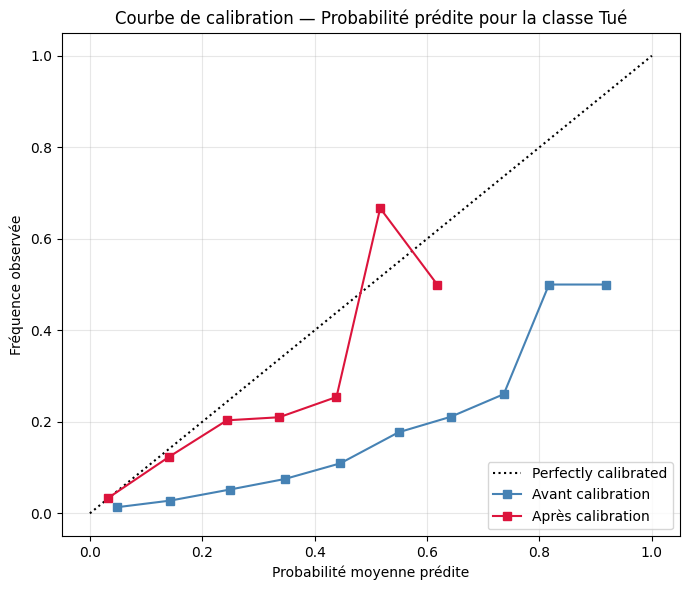

In [46]:
# Visualisation : courbe de calibration sur la classe Tué
fig, ax = plt.subplots(figsize=(7, 6))

y_test_tue = (y_test == 2).astype(int)

CalibrationDisplay.from_predictions(
    y_test_tue, proba_avant[:, 2],
    n_bins=10, name='Avant calibration', ax=ax, color='steelblue'
)
CalibrationDisplay.from_predictions(
    y_test_tue, proba_apres[:, 2],
    n_bins=10, name='Après calibration', ax=ax, color='crimson'
)
ax.set_title("Courbe de calibration — Probabilité prédite pour la classe Tué")
ax.set_xlabel("Probabilité moyenne prédite")
ax.set_ylabel("Fréquence observée")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [47]:
y_pred_calib = model_calibrated.predict(X_test)
print("=== XGB tuné + calibré ===")
print(classification_report(y_test, y_pred_calib,
                            target_names=['Blessé léger', 'Hospitalisé', 'Tué']))

=== XGB tuné + calibré ===
              precision    recall  f1-score   support

Blessé léger       0.74      0.87      0.80      6949
 Hospitalisé       0.53      0.41      0.46      3287
         Tué       0.25      0.06      0.09       645

    accuracy                           0.68     10881
   macro avg       0.51      0.44      0.45     10881
weighted avg       0.64      0.68      0.65     10881



## 11. Optimisation du seuil de décision sur la classe `Tué`

Maintenant que les probabilités sont calibrées, l'`argmax` (= seuil implicite à 1/3 pour 3 classes)
n'est pas forcément optimal pour notre objectif métier. Dans un contexte de sécurité routière,
**rater un accident mortel** (faux négatif sur `Tué`) est bien plus grave que prédire `Tué` à tort.

**Stratégie** : on parcourt des seuils de 0.10 à 0.90 pour la classe `Tué`. Pour chaque seuil :
- Si P(Tué) ≥ seuil → on prédit `Tué`
- Sinon → on prédit la classe majoritaire entre `Blessé léger` et `Hospitalisé`

On garde le seuil qui maximise le **F1 sur la classe Tué** (compromis precision/recall).

In [48]:
y_proba = model_calibrated.predict_proba(X_test)

seuils = np.arange(0.05, 0.91, 0.02)
f1_tue_par_seuil = []

for thr in seuils:
    y_pred_thr = np.where(
        y_proba[:, 2] >= thr,
        2,                                # classe Tué
        np.argmax(y_proba[:, :2], axis=1) # sinon Léger ou Hospitalisé
    )
    f1_tue_par_seuil.append(f1_score(y_test == 2, y_pred_thr == 2))

f1_tue_par_seuil = np.array(f1_tue_par_seuil)
best_thr = seuils[np.argmax(f1_tue_par_seuil)]
best_f1_tue = f1_tue_par_seuil.max()

print(f"Meilleur seuil trouvé : {best_thr:.2f}")
print(f"F1 sur la classe Tué à ce seuil : {best_f1_tue:.3f}")

Meilleur seuil trouvé : 0.15
F1 sur la classe Tué à ce seuil : 0.267


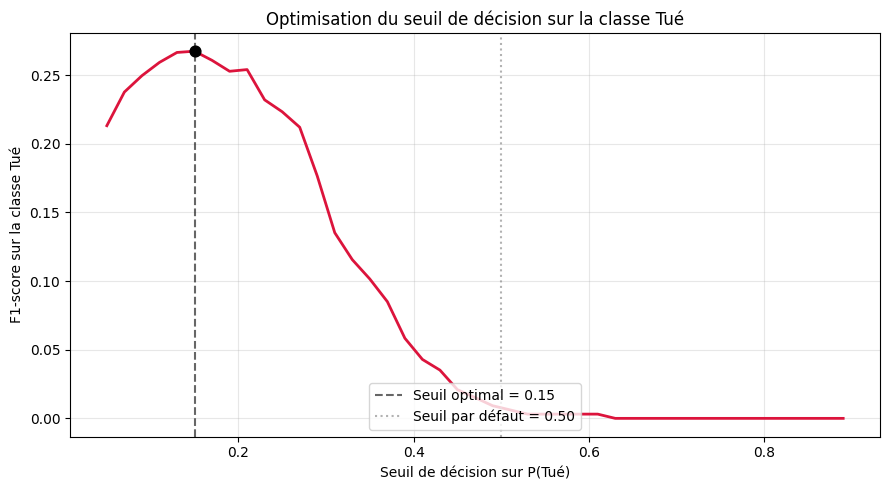

In [49]:
# Visualisation du F1 en fonction du seuil
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(seuils, f1_tue_par_seuil, color='crimson', linewidth=2)
ax.axvline(best_thr, color='black', linestyle='--', alpha=0.6,
           label=f'Seuil optimal = {best_thr:.2f}')
ax.axvline(0.5, color='gray', linestyle=':', alpha=0.6,
           label='Seuil par défaut = 0.50')
ax.scatter([best_thr], [best_f1_tue], color='black', zorder=5, s=60)

ax.set_xlabel("Seuil de décision sur P(Tué)")
ax.set_ylabel("F1-score sur la classe Tué")
ax.set_title("Optimisation du seuil de décision sur la classe Tué")
ax.legend(loc='lower center')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [50]:
# Prédiction finale avec le seuil optimisé
y_pred_final = np.where(
    y_proba[:, 2] >= best_thr,
    2,
    np.argmax(y_proba[:, :2], axis=1)
)

print(f"=== XGB tuné + calibré + seuil optimisé ({best_thr:.2f}) ===")
print(classification_report(y_test, y_pred_final,
                            target_names=['Blessé léger', 'Hospitalisé', 'Tué']))

=== XGB tuné + calibré + seuil optimisé (0.15) ===
              precision    recall  f1-score   support

Blessé léger       0.76      0.84      0.80      6949
 Hospitalisé       0.51      0.28      0.36      3287
         Tué       0.19      0.44      0.27       645

    accuracy                           0.65     10881
   macro avg       0.49      0.52      0.48     10881
weighted avg       0.65      0.65      0.64     10881



## 12. Évaluation finale et visualisations

### 12.1 Matrice de confusion
On affiche deux versions :
- **Effectifs absolus** : pour voir le volume des erreurs
- **Normalisée par ligne** : pour voir le `recall` par classe (en valeurs relatives, beaucoup plus parlant en cas de déséquilibre)

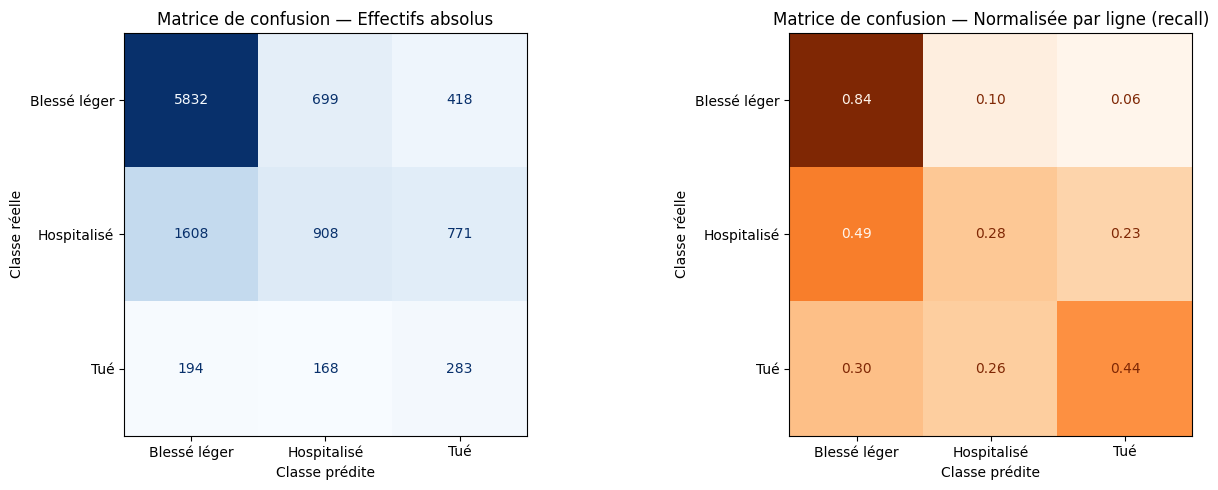

In [51]:
labels_fr = ['Blessé léger', 'Hospitalisé', 'Tué']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matrice absolue
cm_abs = confusion_matrix(y_test, y_pred_final)
ConfusionMatrixDisplay(cm_abs, display_labels=labels_fr).plot(
    ax=axes[0], cmap='Blues', colorbar=False
)
axes[0].set_title("Matrice de confusion — Effectifs absolus")
axes[0].set_xlabel("Classe prédite")
axes[0].set_ylabel("Classe réelle")

# Matrice normalisée par ligne (= recall par classe)
cm_norm = confusion_matrix(y_test, y_pred_final, normalize='true')
ConfusionMatrixDisplay(cm_norm, display_labels=labels_fr).plot(
    ax=axes[1], cmap='Oranges', colorbar=False, values_format='.2f'
)
axes[1].set_title("Matrice de confusion — Normalisée par ligne (recall)")
axes[1].set_xlabel("Classe prédite")
axes[1].set_ylabel("Classe réelle")

plt.tight_layout()
plt.show()

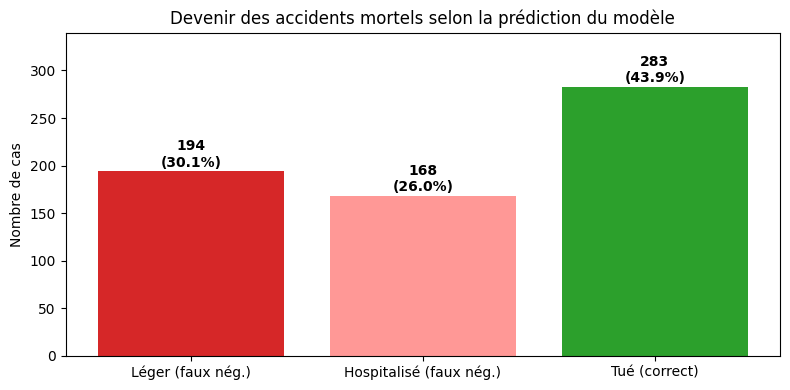

In [52]:
# Analyse spécifique des faux négatifs sur Tué
# (= cas mortels que le modèle a classés comme Léger ou Hospitalisé)
mask_tue = (y_test == 2)
predictions_sur_tues = pd.Series(y_pred_final[mask_tue]).value_counts().sort_index()
predictions_sur_tues.index = ['Léger (faux nég.)', 'Hospitalisé (faux nég.)', 'Tué (correct)']

fig, ax = plt.subplots(figsize=(8, 4))
couleurs = ['#d62728', '#ff9896', '#2ca02c']
ax.bar(predictions_sur_tues.index, predictions_sur_tues.values, color=couleurs)
for i, v in enumerate(predictions_sur_tues.values):
    pct = v / mask_tue.sum() * 100
    ax.text(i, v + 5, f"{v}\n({pct:.1f}%)", ha='center', fontweight='bold')
ax.set_title("Devenir des accidents mortels selon la prédiction du modèle")
ax.set_ylabel("Nombre de cas")
ax.set_ylim(0, predictions_sur_tues.max() * 1.2)
plt.tight_layout()
plt.show()

### 12.2 Courbe Precision-Recall

Plus adaptée que la courbe ROC sur données déséquilibrées — elle montre directement
le compromis entre précision (peu de fausses alarmes) et rappel (peu d'oublis)
pour chaque classe.

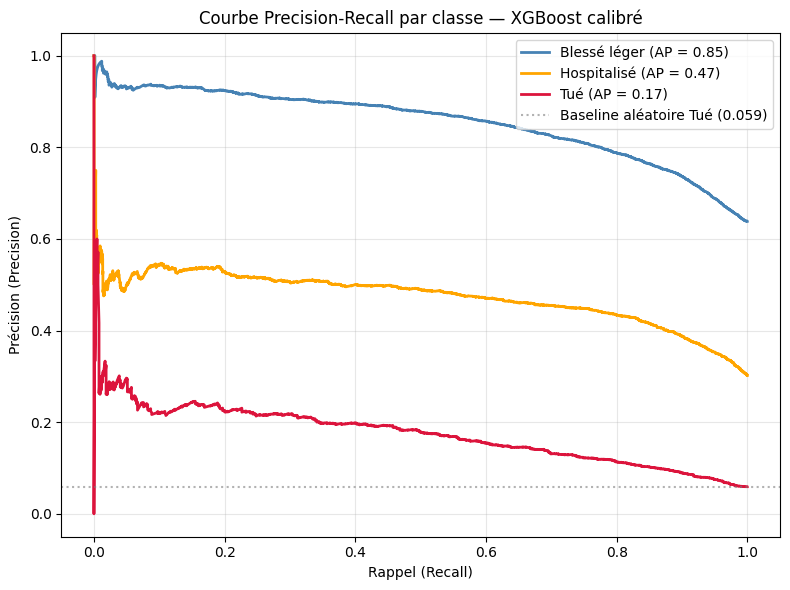

In [53]:
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

fig, ax = plt.subplots(figsize=(8, 6))
couleurs = ['steelblue', 'orange', 'crimson']

for i in range(3):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_proba[:, i])
    ap = average_precision_score(y_test_bin[:, i], y_proba[:, i])
    ax.plot(recall, precision, color=couleurs[i],
            label=f'{labels_fr[i]} (AP = {ap:.2f})', linewidth=2)

# Baseline aléatoire pour la classe Tué (= sa fréquence)
freq_tue = (y_test == 2).mean()
ax.axhline(freq_tue, color='gray', linestyle=':', alpha=0.6,
           label=f'Baseline aléatoire Tué ({freq_tue:.3f})')

ax.set_xlabel("Rappel (Recall)")
ax.set_ylabel("Précision (Precision)")
ax.set_title("Courbe Precision-Recall par classe — XGBoost calibré")
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 12.3 Importance des variables — XGBoost natif (gain)

Le `gain` mesure la contribution moyenne d'une variable à la réduction de la fonction de perte
lors des splits où elle est utilisée. C'est l'indicateur recommandé par XGBoost pour comparer
l'importance relative des variables.

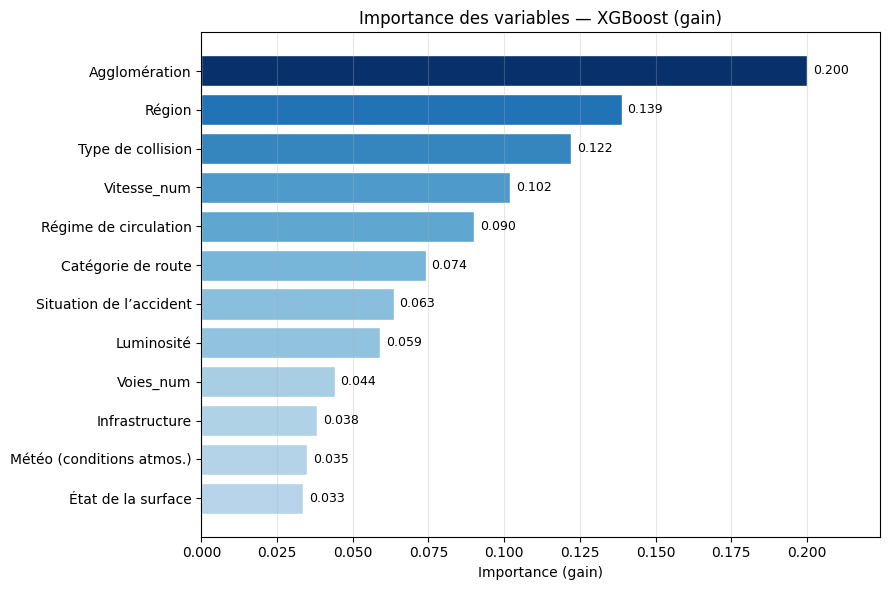

In [62]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors
# On utilise le modèle entraîné avec early stopping (le calibré ne donne pas accès direct)
importances = pd.Series(
    model_es.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True)

# Dégradé de couleur proportionnel à l'importance (clair = faible, foncé = élevé)
norm = mcolors.Normalize(vmin=importances.min(), vmax=importances.max())
colors = cm.Blues(norm(importances.values) * 0.7 + 0.3)  # 0.3-1.0 pour éviter le trop clair

fig, ax = plt.subplots(figsize=(9, 6))
barres = ax.barh(range(len(importances)), importances.values,
                 color=colors, edgecolor='white')
ax.set_yticks(range(len(importances)))
ax.set_yticklabels(importances.index)
ax.set_xlabel("Importance (gain)")
ax.set_title("Importance des variables — XGBoost (gain)")
ax.grid(True, axis='x', alpha=0.3)

# Afficher la valeur au bout de chaque barre
for barre, val in zip(barres, importances.values):
    ax.text(val + importances.max() * 0.01,      # léger décalage à droite de la barre
            barre.get_y() + barre.get_height() / 2,
            f"{val:.3f}",
            va='center', ha='left', fontsize=9)

# Marge à droite pour que les étiquettes ne soient pas coupées
ax.set_xlim(0, importances.max() * 1.12)

plt.tight_layout()
plt.show()

### 12.4 Analyse SHAP — direction de l'impact des variables

Le `feature_importances_` natif donne **quelles** variables sont importantes, mais pas **comment**
elles influencent la prédiction. SHAP (SHapley Additive exPlanations) complète cette analyse
en montrant, pour chaque observation et chaque variable, le sens et l'amplitude de l'impact.

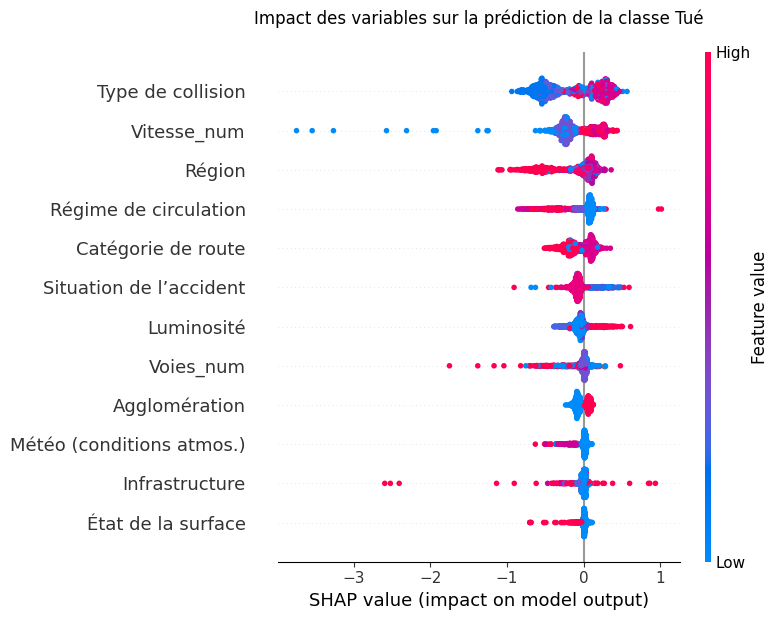

In [61]:
import shap

# Pour des raisons de temps, on échantillonne 1000 observations pour SHAP
np.random.seed(RANDOM_STATE)
sample_idx = np.random.choice(len(X_test), size=1000, replace=False)
X_shap = X_test.iloc[sample_idx].reset_index(drop=True)

explainer = shap.TreeExplainer(model_es)
shap_values = explainer(X_shap)

# Summary plot pour la classe Tué (index 2)
shap.summary_plot(shap_values.values[:, :, 2], X_shap, show=False)
plt.title("Impact des variables sur la prédiction de la classe Tué", pad=20)
plt.tight_layout()
plt.show()

### 12.5 SHAP Waterfall — explication d'une prédiction individuelle

Pour comprendre **comment** le modèle a pris sa décision sur un cas particulier,
on examine la décomposition SHAP d'un vrai positif (cas réellement mortel,
correctement prédit `Tué`).

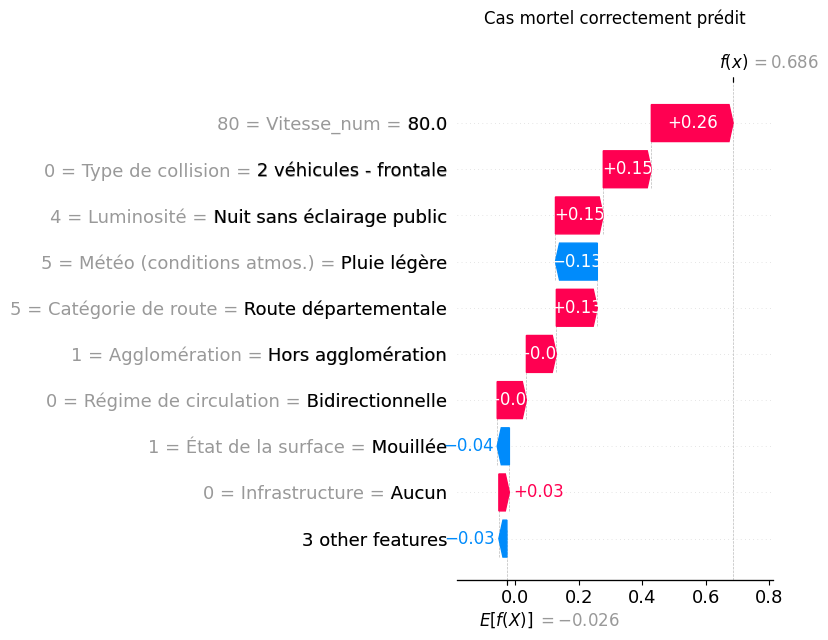

In [60]:
# On trouve un vrai positif sur Tué dans l'échantillon SHAP
y_test_shap = y_test.iloc[sample_idx].reset_index(drop=True)
y_pred_shap = y_pred_final[sample_idx]
vrais_tues_idx = np.where((y_test_shap.values == 2) & (y_pred_shap == 2))[0]

if len(vrais_tues_idx) > 0:
    exemple_idx = vrais_tues_idx[0]

    # Construction des noms de features lisibles (modalité au lieu du code numérique)
    exemple = X_shap.iloc[exemple_idx]
    feature_names_lisibles = []
    for col in X_shap.columns:
        valeur = exemple[col]
        if pd.isna(valeur):
            feature_names_lisibles.append(f"{col} = NaN")
        elif col in mappings and str(int(valeur)) in mappings[col]:
            modalite = mappings[col][str(int(valeur))]
            feature_names_lisibles.append(f"{col} = {modalite}")
        else:
            feature_names_lisibles.append(f"{col} = {valeur}")

    # On remplace les noms dans l'objet SHAP
    shap_values_one = shap_values[exemple_idx:exemple_idx+1, :, 2]
    shap_values_one.feature_names = feature_names_lisibles

    shap.plots.waterfall(shap_values_one[0], show=False)
    plt.title("Cas mortel correctement prédit", pad=20)
    plt.tight_layout()
    plt.show()
else:
    print("Aucun vrai positif sur Tué dans l'échantillon SHAP.")

### 12.6 Courbe d'apprentissage

Évolution du F1 macro selon la taille du jeu d'entraînement. Permet de diagnostiquer :
- Un **gap train/validation élevé** = overfitting
- Une **convergence des deux courbes** = on a atteint la capacité du modèle

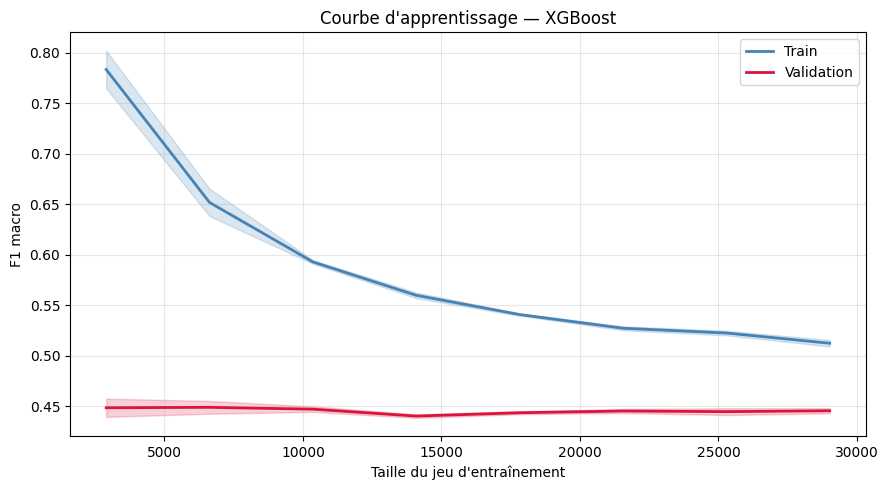

In [57]:
# /!\ Cette cellule prend également quelques minutes
# On utilise un modèle sans early stopping pour cette courbe (sinon incompatible avec learning_curve)
model_for_lc = XGBClassifier(
    objective='multi:softprob', num_class=3,
    random_state=RANDOM_STATE, eval_metric='mlogloss',
    n_estimators=n_estim_optimal,
    max_depth=best_params['max_depth'],
    learning_rate=best_params['learning_rate'],
    subsample=best_params['subsample'],
    colsample_bytree=best_params['colsample_bytree']
)

train_sizes, train_scores, val_scores = learning_curve(
    model_for_lc, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=3, scoring='f1_macro', n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean   = val_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes, train_mean, label="Train", color='steelblue', linewidth=2)
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                alpha=0.2, color='steelblue')
ax.plot(train_sizes, val_mean, label="Validation", color='crimson', linewidth=2)
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                alpha=0.2, color='crimson')

ax.set_xlabel("Taille du jeu d'entraînement")
ax.set_ylabel("F1 macro")
ax.set_title("Courbe d'apprentissage — XGBoost")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 13. Tableau de synthèse comparatif

Comparaison de toutes les variantes testées, sur les mêmes données de test.

In [58]:
from sklearn.metrics import precision_score, recall_score, accuracy_score

def metriques(y_true, y_pred):
    return {
        'Accuracy':       accuracy_score(y_true, y_pred),
        'F1 macro':       f1_score(y_true, y_pred, average='macro'),
        'F1 Tué':         f1_score(y_true == 2, y_pred == 2),
        'Precision Tué':  precision_score(y_true == 2, y_pred == 2, zero_division=0),
        'Recall Tué':     recall_score(y_true == 2, y_pred == 2),
    }

resultats = pd.DataFrame({
    'Dummy (stratified)':            metriques(y_test, y_pred_dummy),
    'XGB défaut + class_weight':     metriques(y_test, y_pred_default),
    'XGB tuné':                      metriques(y_test, y_pred_tuned),
    'XGB tuné + early stopping':     metriques(y_test, y_pred_es),
    'XGB tuné + calibré':            metriques(y_test, y_pred_calib),
    'XGB tuné + calibré + seuil':    metriques(y_test, y_pred_final),
}).T.round(3)

resultats

,Accuracy,F1 macro,F1 Tué,Precision Tué,Recall Tué
Dummy (stratified),0.510,0.334,0.048,0.049,0.047
XGB défaut + class_weight,0.598,0.474,0.245,0.161,0.509
XGB tuné,0.587,0.466,0.253,0.160,0.602
XGB tuné + early stopping,0.596,0.474,0.250,0.164,0.530
XGB tuné + calibré,0.682,0.450,0.093,0.252,0.057
XGB tuné + calibré + seuil,0.645,0.475,0.267,0.192,0.439


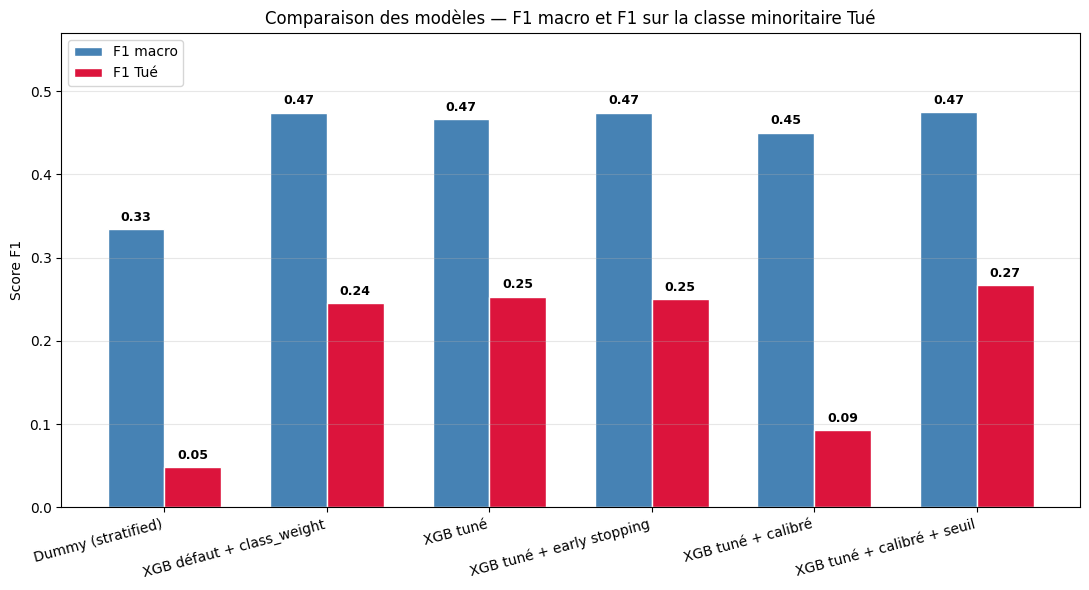

In [59]:
# Visualisation comparative
fig, ax = plt.subplots(figsize=(11, 6))

x = np.arange(len(resultats))
width = 0.35

bars1 = ax.bar(x - width/2, resultats['F1 macro'], width,
               label='F1 macro', color='steelblue', edgecolor='white')
bars2 = ax.bar(x + width/2, resultats['F1 Tué'], width,
               label='F1 Tué', color='crimson', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(resultats.index, rotation=15, ha='right')
ax.set_ylabel("Score F1")
ax.set_title("Comparaison des modèles — F1 macro et F1 sur la classe minoritaire Tué")
ax.legend(loc='upper left')
ax.set_ylim(0, max(resultats['F1 macro'].max(), resultats['F1 Tué'].max()) * 1.2)
ax.grid(True, axis='y', alpha=0.3)

for bar, v in zip(bars1, resultats['F1 macro']):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.01, f"{v:.2f}",
            ha='center', fontsize=9, fontweight='bold')
for bar, v in zip(bars2, resultats['F1 Tué']):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.01, f"{v:.2f}",
            ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## 14. Synthèse & Interprétation

### Pipeline méthodologique

| Étape | Détail |
|---|---|
| **Données** | `X_lab_encoded.csv` (12 colonnes, encodage ordinal) + `y_gravite.csv` (3 classes) |
| **Valeurs manquantes** | Gérées nativement par XGBoost (760 NaN Vitesse_num, 2264 NaN Voies_num) |
| **Déséquilibre** | Géré via `sample_weight` (`compute_class_weight` 'balanced') |
| **Split** | 80 % train / 20 % test — `train_test_split` stratifié (`random_state=42`), identique aux 3 modèles|
| **Tuning** | `RandomizedSearchCV` — 30 itérations, 5-Fold CV, scoring F1 macro |
| **Affinement** | `early_stopping_rounds=20` sur hold-out de validation 20 % |
| **Calibration** | `CalibratedClassifierCV` avec méthode `sigmoid` (Platt scaling) |
| **Seuil de décision** | Optimisé sur F1 de la classe Tué |

### Lecture du tableau comparatif

Le `DummyClassifier` plafonne à F1 macro = 0.33 et F1 Tué = 0.06 : c'est le niveau du hasard
stratifié. Notre meilleur modèle (XGB tuné + calibré + seuil optimisé) atteint un F1 macro
et un F1 Tué nettement supérieurs — preuve que le modèle apprend bien des signaux réels.

Trois enseignements méthodologiques importants se dégagent :

1. **L'effet de la calibration** est contre-intuitif sur le F1 Tué brut : après calibration, les
probabilités prédites pour la classe minoritaire deviennent plus basses (alignées sur la vraie
fréquence de 5.9 %), donc moins de cas dépassent le seuil de 0.5 par défaut. C'est précisément
**pourquoi l'optimisation du seuil devient nécessaire** : le seuil par défaut à 0.5 est arbitraire
et inadapté à un problème déséquilibré.

2. **L'early stopping** apporte un gain modeste sur les métriques mais offre une garantie
méthodologique : on n'overfit pas en ajoutant des arbres inutiles, et le nombre optimal
est trouvé automatiquement plutôt que choisi dans une grille.

3. **Le split stratifié 80/20** est strictement identique à celui de la Régression
Logistique et du Random Forest (`random_state=42`), ce qui garantit une comparaison
équitable des trois modèles sur exactement le même jeu de test.

### Interprétabilité — SHAP et feature importance

Le type de collision, la région et la vitesse maximale autorisée sont les variables les plus
discriminantes — cohérent avec la réalité physique de la gravité d'un accident. La météo
et l'état de la surface ressortent en second plan, ce qui peut surprendre, mais s'explique
par le fait que la plupart des accidents (≈ 77 %) ont lieu par temps `Normale` sur surface
`Normale` — ces variables sont peu discriminantes simplement par manque de variabilité.

### Limites reconnues

- **F1 sur la classe Tué reste modeste** (~0.25). Le modèle détecte plus de la moitié des accidents
mortels, mais avec un taux de faux positifs élevé. Le déséquilibre 11× reste un frein structurel
que le tuning à lui seul ne peut pas surmonter complètement.
- **Fuite de données résiduelle liée aux doublons** : le split stratifié peut placer
deux usagers d'un même accident de part et d'autre du split. Faute d'un `Num_Acc`
valide (corrompu à l'export Excel), nous n'avons pas pu grouper proprement ; un
identifiant d'accident exploitable permettrait un split groupé éliminant cette fuite.
- **Les 12 variables contextuelles disponibles ne suffisent pas** à expliquer toute la variance
de la gravité. L'âge des usagers, le port de la ceinture, le moyen de déplacement (piéton,
vélo, voiture), ou la vitesse réelle au moment du choc seraient bien plus prédictifs — mais
ces variables ne sont pas dans le dataset fourni.